In [1]:
pip install EMD-signal

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import PyEMD
print(PyEMD.__version__)

1.6.4


In [3]:
import matplotlib.pyplot as plt
# 导入matplotlib的pyplot模块，用于数据可视化。
import tensorflow as tf
# 导入tensorflow库，用于深度学习模型的构建和训练
from PyEMD import EMD, EEMD, CEEMDAN
# 从pyemd库导入EMD, EEMD, CEEMDAN，用于模态分解
import pandas as pd
# 导入pandas库，用于数据处理和分析
import warnings
# 导入warnings库，用于控制警告消息
warnings.filterwarnings("ignore")

C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\111\PycharmProjects\PythonProject1\.venv\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_han

In [4]:
gpus = tf.config.experimental.list_physical_devices(device_type='GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [5]:
# 用来正常显示中文/英文标签（保持与模板一致）
plt.rcParams['font.sans-serif'] = ['Times New Roman']
# 用来正常显示负号
plt.rcParams['axes.unicode_minus'] = False

In [6]:
df_raw_data = pd.read_csv('Vietnam-DroughtPrediction.csv')

# 确保时间列为Datetime并按时间排序
df_raw_data['Month'] = pd.to_datetime(df_raw_data['Month'])
df_raw_data = df_raw_data.sort_values('Month').reset_index(drop=True)

# 只分解目标 cdd（推荐做法），构造与模板一致的 Series 写法
series_close = pd.Series(
    df_raw_data['cdd'].astype(float).values,
    index=df_raw_data['Month']
)
# 创建一个pandas的Series对象。
# df_raw_data['cdd'].values提取'cdd'列的值作为Series的数据。
# index=df_raw_data['Month']设置Series的索引为时间戳（YYYY-MM）
print(series_close)

Month
1950-01-01    13.60
1950-02-01    12.74
1950-03-01    12.64
1950-04-01     8.72
1950-05-01     4.79
              ...  
2023-08-01     3.83
2023-09-01     2.80
2023-10-01     5.30
2023-11-01     7.95
2023-12-01    12.48
Length: 888, dtype: float64


In [7]:
def ceemdan_decompose(series=None, trials=100):
    # 定义CEEMDAN分解函数。
    # series: 待分解的时间序列数据。
    # trials: CEEMDAN的试验次数，用于生成噪声。

    decom = CEEMDAN()
    # 创建CEEMDAN对象。

    decom.trials = trials
    # 设置CEEMDAN对象的试验次数。

    df_ceemdan = pd.DataFrame(decom(series.values).T)
    # 对时间序列数据执行CEEMDAN分解，并将结果转置后转换为DataFrame。

    df_ceemdan.columns = ['imf' + str(i+1) for i in range(len(df_ceemdan.columns))]
    # 为DataFrame的每一列命名，表示每个内在模态函数（IMF）。

    return df_ceemdan
    # 返回分解结果的DataFrame。

In [8]:
df_ceemdan = ceemdan_decompose(series_close)
# 对series_close进行CEEMDAN分解，并返回结果的DataFrame。

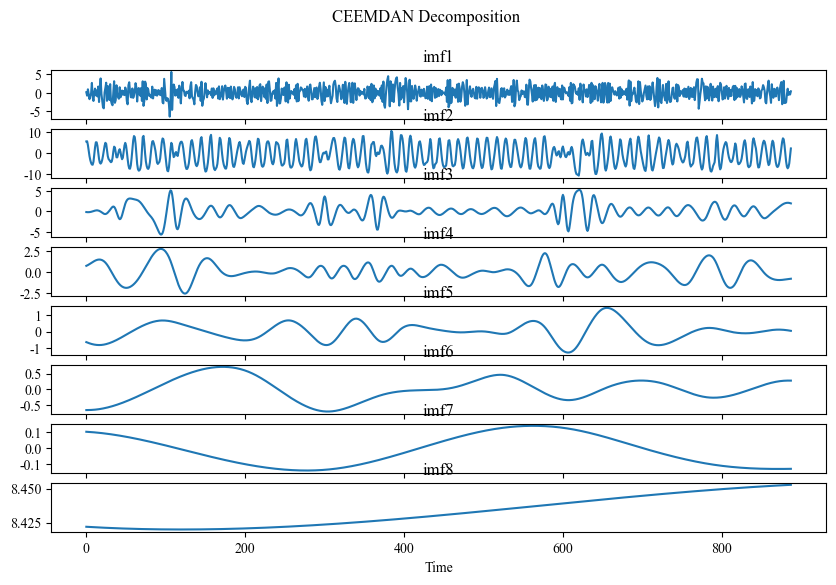

In [9]:
# 可视化VMD分解结果
fig, axs = plt.subplots(nrows=len(df_ceemdan.columns), figsize=(10, 6), sharex=True)
# 创建一个绘图对象和多个子图对象。
for i, col in enumerate(df_ceemdan.columns):
    axs[i].plot(df_ceemdan[col])
    axs[i].set_title(col)
    # 遍历每个模态并绘制在子图上。

plt.suptitle('CEEMDAN Decomposition')
# 设置图表的总标题。

plt.xlabel('Time')
# 设置x轴的标签。

plt.show()
# 显示图表。

In [10]:
print(df_ceemdan)
df_ceemdan.to_excel("CEEMDAN-VIETNAM-CDD.xlsx",index=False)
#保存数据为CEEMDAN-CHINA-CDD.xlsx

         imf1      imf2      imf3      imf4      imf5      imf6      imf7  \
0    0.145630  5.635836 -0.137795  0.738823 -0.643263 -0.661470  0.100238   
1   -0.795574  5.717783 -0.162033  0.782808 -0.663467 -0.661427  0.099943   
2    0.931041  3.870428 -0.171682  0.832433 -0.682623 -0.661162  0.099632   
3   -0.348790  1.189405 -0.167348  0.886897 -0.700698 -0.660672  0.099307   
4   -1.744440 -1.403786 -0.150044  0.945050 -0.717658 -0.659954  0.098966   
..        ...       ...       ...       ...       ...       ...       ...   
883  1.093065 -7.212830  2.129937 -0.853637  0.076990  0.275704 -0.131891   
884 -0.586024 -6.560349  2.120488 -0.840567  0.069682  0.275897 -0.131819   
885  0.175369 -4.797844  2.091945 -0.828164  0.061908  0.275808 -0.131743   
886 -0.482233 -1.446886  2.045264 -0.816364  0.053690  0.275440 -0.131662   
887  0.386511  2.276136  1.981375 -0.805075  0.045052  0.274797 -0.131575   

         imf8  
0    8.422002  
1    8.421967  
2    8.421933  
3    8.4218